# DATA VORTEX — Rebuilding the Social Engine
### End-to-end audit -> clean -> validate -> EDA -> insights pipeline

This notebook reproduces the full analysis using the shared modules in `src/`.
It reads only from `data/raw/` (never modified) and writes cleaned data to
`data/cleaned/`, figures to `reports/figures/`, and text reports to `reports/`.

Run this notebook from the **project root** (`datavortex/`), or run
`jupyter nbconvert --execute` from the project root as done for this
submission.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
os.chdir('..')  # run from project root so relative paths (data/, reports/) resolve
import pandas as pd
pd.set_option('display.max_columns', None)
print('Working directory:', os.getcwd())

Working directory: /home/claude/datavortex


## 1. Audit the raw data
Quantifies every data quality issue before touching anything.

In [2]:
import subprocess
result = subprocess.run(['python3', 'src/01_audit_raw_data.py'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Audit complete. Report written to reports/audit_report.md
Users rows: 1500 | Posts rows: 12360




In [3]:
with open('reports/audit_report.md') as f:
    print(f.read())

# DATA VORTEX — Raw Data Audit Report

Generated by `src/01_audit_raw_data.py`. Source files are read only from `data/raw/` and are never modified.

## Users table (`Social_Engine_Users.csv`)

- Rows: 1500
- Columns: ['user_id', 'location', 'language', 'account_created', 'follower_count']
- Duplicate `user_id` values: 0
- Fully duplicated rows: 0
- `user_id`: 0 missing/placeholder values
- `location`: 0 missing/placeholder values
- `language`: 0 missing/placeholder values
- `account_created`: 0 missing/placeholder values
- `follower_count`: 0 missing/placeholder values
- `follower_count` non-numeric entries: 0
- `follower_count` negative values: 0
- `follower_count` range: 109 to 49944
- `account_created` unparseable dates: 0
- `account_created` range: 2023-01-01 to 2023-12-31
- Distinct `location` values: 33
- Distinct `language` codes: ['ar', 'de', 'en', 'es', 'fr', 'hi', 'ja', 'pt', 'ru', 'zh']
- Overall: users table required only whitespace/dtype normalization; no missing values, n

## 2. Clean the data
Deterministic, documented transformations. Raw files are never modified; missing data is preserved as missing rather than invented.

In [4]:
result = subprocess.run(['python3', 'src/02_clean_data.py'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Cleaned users -> data/cleaned/users_cleaned.csv (1500 rows)
Cleaned posts -> data/cleaned/posts_cleaned.csv (12000 rows)
Cleaning log -> reports/cleaning_log.md




In [5]:
with open('reports/cleaning_log.md') as f:
    print(f.read())

# DATA VORTEX — Cleaning Decision Log

Generated by `src/02_clean_data.py`. Every transformation below is deterministic and reproducible from the raw files in `data/raw/`. No values were invented; missing data is preserved as missing.

## Users cleaning

- Raw rows: 1500
- Whitespace trimmed on `location`/`language`; `account_created` normalized to ISO `YYYY-MM-DD`; `follower_count` cast to int.
- Exact duplicate rows removed: 0
- Final rows: 1500 (no other changes needed — see audit report)

## Posts cleaning

- Raw rows: 12360
- Normalized literal `NULL`/empty-string placeholders to real missing values: platform=1846, text_content=1770, likes=1858. **These rows are kept** (not dropped) — the missing field just isn't usable for analyses that need it.
- Decoded HTML entities (e.g. `&amp;` -> `&`) and trimmed stray whitespace in `text_content` and `platform`.
- Parsed 3 mixed timestamp formats (unix epoch, ISO 8601, `DD-MM-YYYY`) into a single standardized `event_time` column. Unparseab

## 3. Validate the cleaned data
A battery of pass/fail checks against the cleaned CSVs.

In [6]:
result = subprocess.run(['python3', 'src/03_validate_cleaned_data.py'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)
assert result.returncode == 0, "Validation failed — see reports/validation_report.md"


Validation complete: 15/15 checks passed.




In [7]:
validation = pd.read_csv('reports/validation_report.md', sep='|', skiprows=6, engine='python',
                          names=['_', 'n', 'check', 'result', 'detail', '__'])
validation = validation[['n', 'check', 'result', 'detail']].dropna(subset=['check'])
validation.head(20)

,n,check,result,detail
0,1.0,Users: no duplicate user_id,PASS,0 duplicates found
1,2.0,Users: no missing values in any column,PASS,0 missing cells
2,3.0,Users: follower_count is non-negative,PASS,min=109
3,4.0,Users: account_created parses as valid dates,PASS,
4,5.0,Posts: no fully duplicated rows,PASS,0 duplicate rows
5,6.0,Posts: post_id is unique,PASS,0 duplicate post_ids
6,7.0,Posts: every user_id exists in the users table,PASS,0 orphan rows
7,8.0,Posts: likes has no negative values (NaN allo...,PASS,0 negative values remain
8,9.0,Posts: shares has no missing or negative values,PASS,
9,10.0,Posts: comments has no missing or negative va...,PASS,


## 4. Exploratory Data Analysis
Load the cleaned data directly and look at shape, types, and summary stats before regenerating the figures used in the report.

In [8]:
users = pd.read_csv('data/cleaned/users_cleaned.csv', parse_dates=['account_created'])
posts = pd.read_csv('data/cleaned/posts_cleaned.csv', parse_dates=['event_time'])
print(users.shape, posts.shape)
users.head()

(1500, 5) (12000, 9)


,user_id,location,language,account_created,follower_count
0,user_guglt5jp,"Berlin, Germany",ja,2023-10-23,38963
1,user_b1p3wz81,"Munich, Germany",zh,2023-05-06,24644
2,user_jm2grmis,"Dubai, UAE",en,2023-01-03,45842
3,user_ykoqww5l,"Paris, France",fr,2023-10-11,665
4,user_3zzvv8vp,"Los Angeles, USA",ru,2023-05-23,42908


In [9]:
posts.head()

,post_id,user_id,platform,text_content,timestamp_raw,event_time,likes,shares,comments
0,fqllh9kch4ed,user_njtvacei,Facebook,Attended the Toyota ReferralBonus event yester...,01-05-2024,2024-05-01,NaN,1515,641
1,s470ok7hizhu,user_g8q08z4s,Twitter,Just unboxed my new iMac from Apple. Best purc...,01-05-2024,2024-05-01,4509.0,1080,541
2,8mq28zl0awbw,user_u6wmhba1,Twitter,Bummed out with my new Ultraboost from Adidas!...,01-05-2024,2024-05-01,565.0,1470,615
3,xlypry3j4ovu,user_g2dekwc7,YouTube,Comparing Samsung Neo QLED TV to the competiti...,01-05-2024,2024-05-01,2810.0,523,471
4,4k2j4x88oh1s,user_8ryfkdug,Facebook,My one week review of Coca-Cola Sprite: Absolu...,01-05-2024,2024-05-01,1622.0,527,102


In [10]:
posts.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
post_id,12000,12000,fqllh9kch4ed,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,12000,1500,user_zqv2vrf5,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform,10216,5,Facebook,2074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text_content,10289,10224,NULL&,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp_raw,12000,8839,25-02-2025,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_time,12000,NaN,NaN,NaN,2024-10-30 05:40:29.458750,2024-05-01 00:00:00,2024-07-31 14:06:23,2024-10-31 00:00:00,2025-01-28 11:11:21,2025-04-30 21:57:10,NaN
likes,10186.0,NaN,NaN,NaN,2491.864716,0.0,1236.0,2498.0,3722.75,5000.0,1437.826281
shares,12000.0,NaN,NaN,NaN,1007.167167,0.0,510.0,1018.0,1501.0,2000.0,575.072282
comments,12000.0,NaN,NaN,NaN,504.34575,0.0,253.0,503.0,755.0,1000.0,288.68416


In [11]:
result = subprocess.run(['python3', 'src/04_eda_and_visuals.py'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

saved reports/figures/01_posts_by_platform.png
Posts by platform:
 platform
Facebook     2074
YouTube      2073
Twitter      2049
Reddit       2031
Instagram    1989
Name: count, dtype: int64 

saved reports/figures/02_engagement_distributions.png
saved reports/figures/03_monthly_post_volume.png
saved reports/figures/04_engagement_by_platform.png
Mean engagement by platform:
                  likes       shares    comments
platform                                       
Facebook   2528.855271   984.173578  506.936837
Instagram  2500.926167  1040.836099  499.804424
Reddit     2488.114811  1002.228951  511.175283
Twitter    2437.690435  1005.391410  506.126403
YouTube    2517.769891  1011.828751  504.380125 

saved reports/figures/05_followers_vs_engagement.png
Correlation(follower_count, engagement) = -0.0109

saved reports/figures/06_top_hashtags.png
saved reports/figures/07_users_by_language.png
saved reports/figures/08_residual_missingness.png
EDA complete. Figures saved to reports/f

### Figures
Generated into `reports/figures/` by the cell above; displayed inline below.

reports/figures/01_posts_by_platform.png


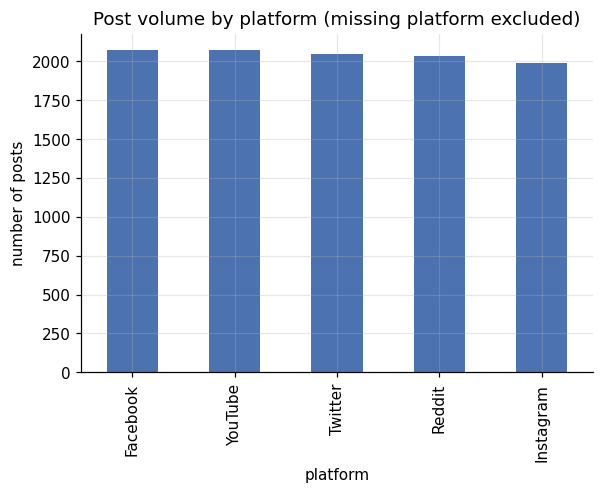

reports/figures/02_engagement_distributions.png


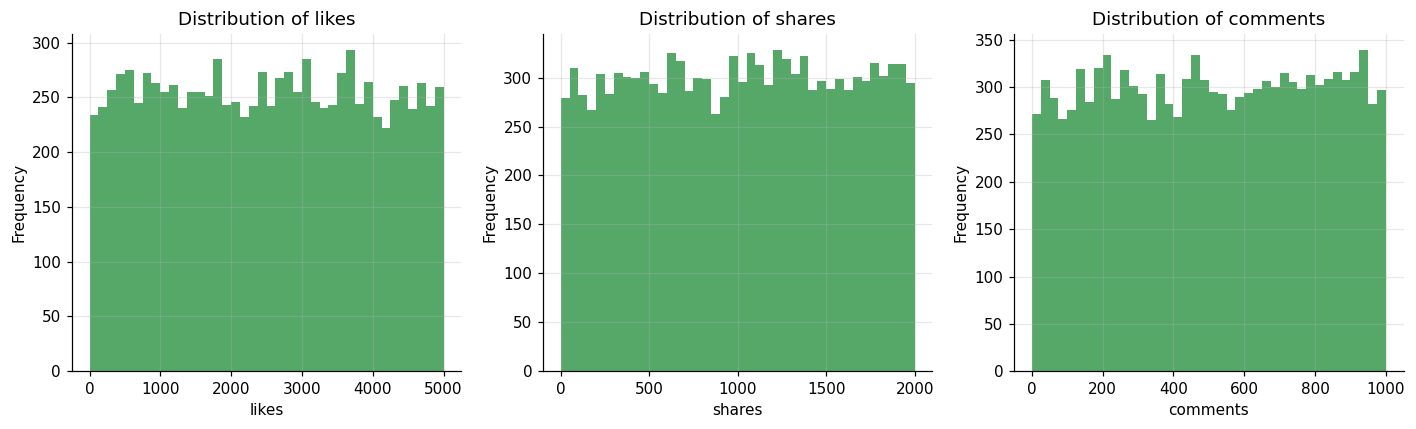

reports/figures/03_monthly_post_volume.png


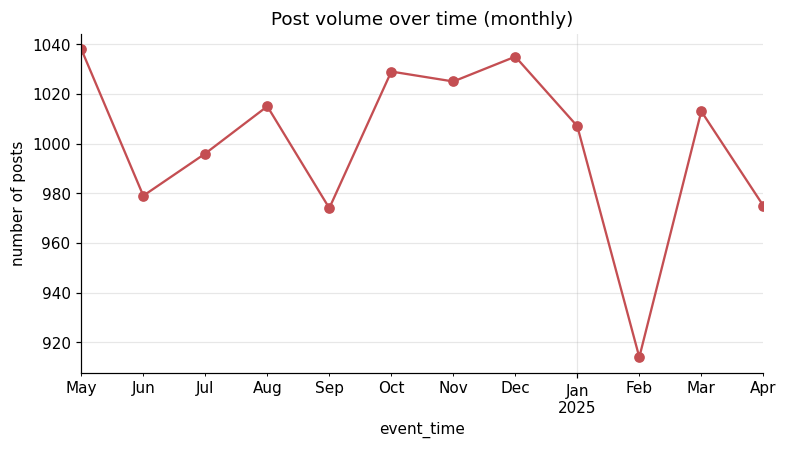

reports/figures/04_engagement_by_platform.png


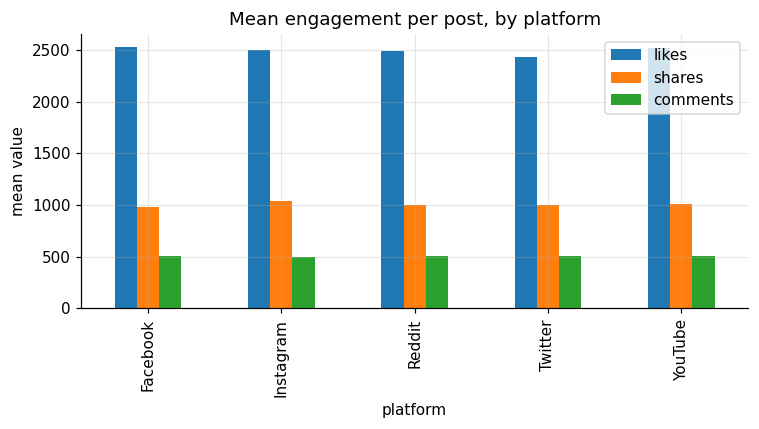

reports/figures/05_followers_vs_engagement.png


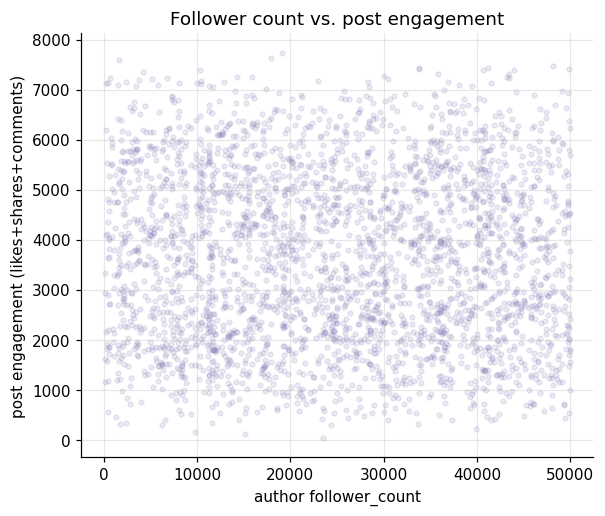

reports/figures/06_top_hashtags.png


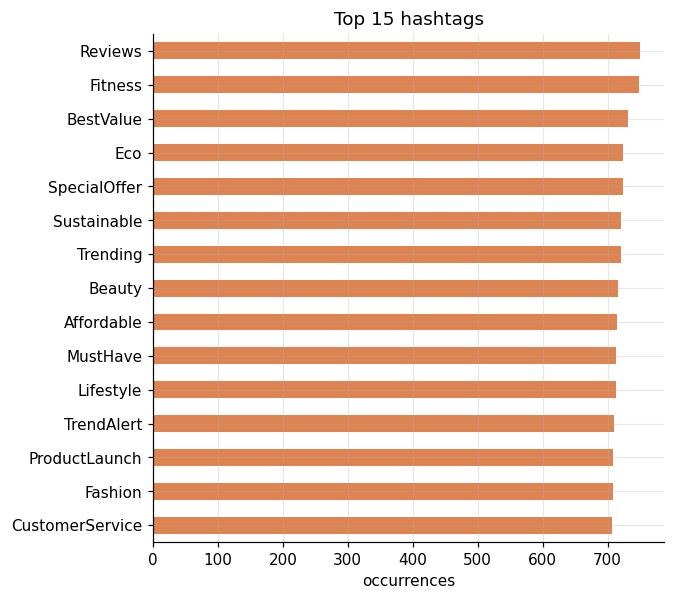

reports/figures/07_users_by_language.png


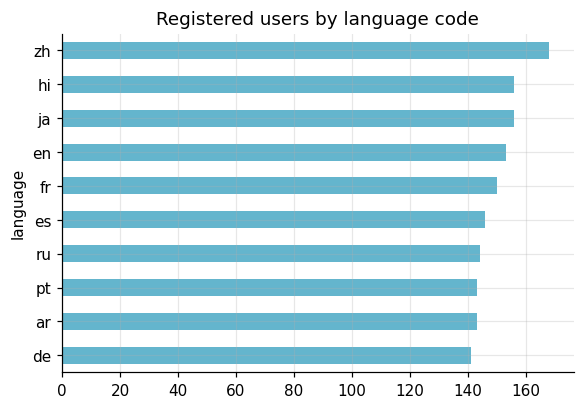

reports/figures/08_residual_missingness.png


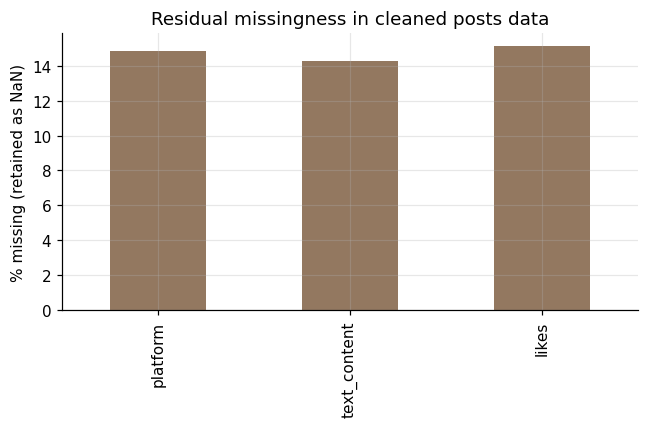

In [12]:
from IPython.display import Image, display
import glob
for path in sorted(glob.glob('reports/figures/*.png')):
    print(path)
    display(Image(filename=path))

## 5. Insights — Rebuilding the Social Engine
Non-obvious, data-backed findings computed straight from the cleaned data.

In [13]:
result = subprocess.run(['python3', 'src/05_insights.py'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Insights written to reports/insights.md
Key numbers — follower/engagement corr: -0.0109, platform engagement spread: 3.0%, contradictory-sentiment posts: 310




In [14]:
with open('reports/insights.md') as f:
    print(f.read())

# DATA VORTEX — Insights: Rebuilding the Social Engine

All figures below are computed directly from `data/cleaned/*.csv` by `src/05_insights.py`.

## 1. Follower count is not a usable proxy for engagement or reach

- Correlation between author `follower_count` and total post engagement (likes+shares+comments): **r = -0.011**
- Correlation between `follower_count` and `likes` alone: r = 0.008
- Mean engagement for the top 10% most-followed authors (follower_count >= 44363): **3587**
- Mean engagement for the bottom 10% least-followed authors (follower_count <= 5446): **3638**
- The two groups differ by only 1.4%, despite a >100x difference in audience size. **Implication:** a rebuilt recommendation/ranking engine should not weight follower count as a proxy for expected engagement or influence — in this data it carries no signal.

## 2. Engagement is nearly platform-agnostic

Mean total engagement per post, by platform:

- Instagram: 3669
- Reddit: 3647
- YouTube: 3638
- Facebook: 3631


## Summary

See `README.md` for the polished write-up of this project, and `STATE.md` for the current status of the submission. Every number quoted in the README traces back to a cell in this notebook or to `reports/*.md`, which are all regenerated by the `src/*.py` scripts run above.